# Walk-forward Sales Forecasting

## Setup

In [1]:

import os
import warnings


os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

warnings.filterwarnings("ignore")

In [2]:
%%capture

import tensorflow as tf
from tensorflow import keras

tf.get_logger().setLevel("ERROR")

I0000 00:00:1788293151.284951   34066 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788293153.042302   34066 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler


# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Dataset

In [4]:
data = pd.read_csv(
    "data/daily_sales.csv",
    parse_dates=["date"],
    index_col="date"
)

data = data.sort_index()

## Data Preparation

In [5]:
# Basic data quality checks

print("Shape:", data.shape)
print("\nMissing values:")
print(data.isna().sum())

print("\nDuplicate dates:", data.index.duplicated().sum())

print("\nDate range:")
print(data.index.min(), "to", data.index.max())

Shape: (3107, 1)

Missing values:
sales    0
dtype: int64

Duplicate dates: 0

Date range:
2016-06-01 00:00:00 to 2026-08-22 00:00:00


In [6]:
# Check missing calendar dates
full_dates = pd.date_range(data.index.min(), data.index.max(), freq="D")
missing_dates = full_dates.difference(data.index)

print("Missing calendar dates:", len(missing_dates))
missing_dates[:10]

Missing calendar dates: 628


DatetimeIndex(['2016-06-05', '2016-06-12', '2016-06-19', '2016-06-26',
               '2016-07-03', '2016-07-10', '2016-07-17', '2016-07-24',
               '2016-07-31', '2016-08-07'],
              dtype='datetime64[us]', freq=None)

In [7]:
# Walk-forward evaluation setup

holdout_start = pd.Timestamp("2026-06-29")
holdout_end = pd.Timestamp("2026-08-22")

# Keep full data only for slicing historical data and checking final answers
data2 = data.copy()

# EDA should only use data before the holdout period
eda_data = data2.loc[data2.index < holdout_start].copy()

# Final holdout period used only for evaluation
actual_sales = data2.loc[holdout_start:holdout_end].copy()

# Remove Sundays from the evaluation target
actual_sales = actual_sales[actual_sales.index.weekday != 6].copy()

actual_sales = actual_sales[["sales"]].copy()
actual_sales["forecast_date"] = actual_sales.index

actual_sales["week_start"] = (
    actual_sales["forecast_date"]
    - pd.to_timedelta(actual_sales["forecast_date"].dt.weekday, unit="D")
)

actual_sales["horizon"] = actual_sales.groupby("week_start").cumcount() + 1

actual_sales = actual_sales.rename(columns={"sales": "y_true"})
actual_sales = actual_sales.reset_index(drop=True)

week_starts = sorted(actual_sales["week_start"].unique())

actual_sales.head()

,y_true,forecast_date,week_start,horizon
0,173.73,2026-06-29,2026-06-29,1
1,138.39,2026-06-30,2026-06-29,2
2,132.92,2026-07-01,2026-06-29,3
3,172.33,2026-07-02,2026-06-29,4
4,125.24,2026-07-03,2026-06-29,5


In [8]:
actual_sales.groupby("week_start").size()

week_start
2026-06-29    6
2026-07-06    6
2026-07-13    6
2026-07-20    6
2026-07-27    6
2026-08-03    6
2026-08-10    6
2026-08-17    6
dtype: int64

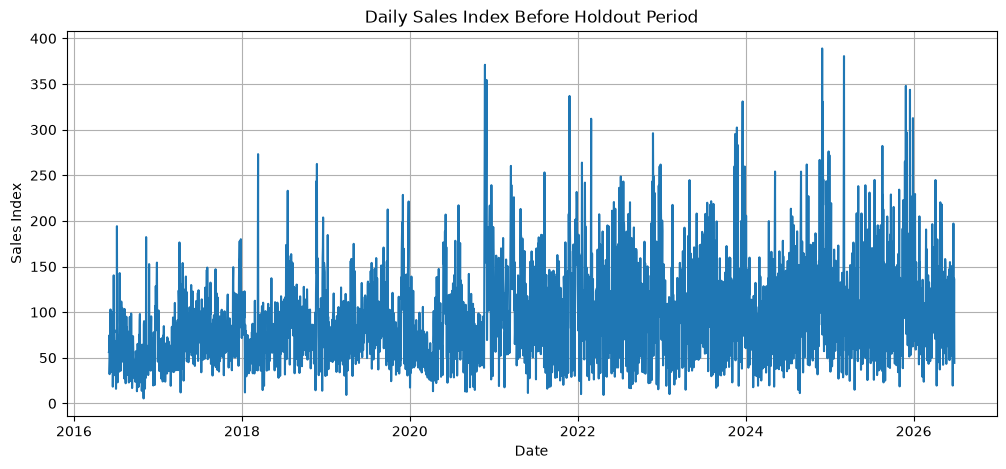

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(eda_data.index, eda_data["sales"])
plt.title("Daily Sales Index Before Holdout Period")
plt.xlabel("Date")
plt.ylabel("Sales Index")
plt.grid(True)
plt.show()

In [10]:
eda_data.describe()

,sales
count,3059.000000
mean,99.603057
std,51.450780
min,5.440000
25%,61.760000
50%,92.040000
75%,126.705000
max,388.960000


In [11]:
adf_test = adfuller(eda_data["sales"])

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

ADF Statistic: -4.73596239313487
p-value: 7.199251973583267e-05


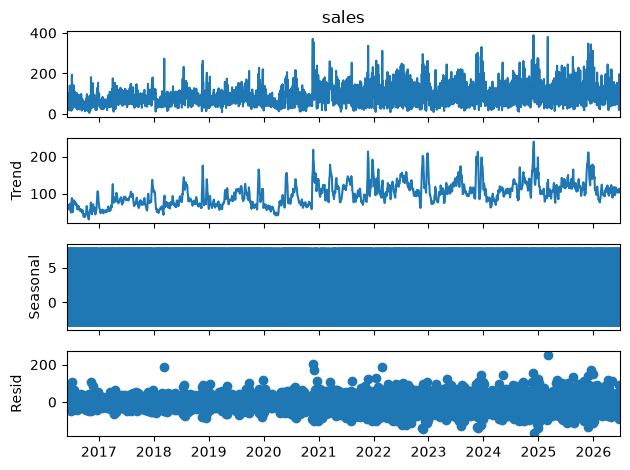

In [12]:
decomposition = seasonal_decompose(
    eda_data["sales"],
    model="additive",
    period=6
)

decomposition.plot()
plt.show()

In [13]:
# Model settings

past_steps = 26
future_steps = 6

past_steps_new = 28
future_steps_new = 7

target_col = "sales"
batch_size = 16
epochs = 200

## Helper Functions

In [14]:
def dataset_to_numpy(ds):
    X_list = []
    Y_list = []

    for X_batch, Y_batch in ds:
        X_list.append(X_batch.numpy())
        Y_list.append(Y_batch.numpy())

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)

    return X, Y

In [15]:
# Function that makes windows of data to be used with the RNNs
def make_windows(series, past_steps, future_steps):
    X, Y = [], []
    for i in range(len(series) - past_steps - future_steps + 1):
        past = series[i:i + past_steps]
        future = series[i + past_steps:i + past_steps + future_steps]
        X.append(past)
        Y.append(future)
    X = np.array(X)[..., np.newaxis]
    Y = np.array(Y)[..., np.newaxis]
    return X, Y

In [16]:

def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

# Function that creates the tensor form for training
def to_seq2seq_dataset(series, seq_length=past_steps, ahead=future_steps, target_col=0, batch_size=16, shuffle=False, seed=42):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0, :], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

#function for Scaling
def scale_current_history(current_history, target_col="sales"):
    scaler = StandardScaler()

    sales = current_history[target_col].values.astype(np.float32)
    sales_scaled = scaler.fit_transform(sales.reshape(-1, 1)).astype(np.float32)

    return sales_scaled, scaler

# Function to be used for inverse transformation
def inverse_transform(series, scaler):
    return scaler.inverse_transform(series.reshape(-1, 1)).reshape(series.shape)

In [17]:
def prepare_rnn_model_data(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    batch_size = 16
):
    sales_scaled, scaler = scale_current_history(current_history, target_col=target_col)

    X_rnn, Y_rnn = make_windows(
        sales_scaled.reshape(-1),
        past_steps=past_steps,
        future_steps=future_steps
    )

    X_next = sales_scaled[-past_steps:].reshape(
        1, past_steps, 1
    ).astype(np.float32)

    return {
        "sales_scaled": sales_scaled,
        "scaler": scaler,
        "X_rnn": X_rnn,
        "Y_rnn": Y_rnn,
        "X_next": X_next
    }

In [18]:
def split_windows_time_order(X, Y, valid_ratio=0.15):
    valid_size = int(len(X) * valid_ratio)

    X_train = X[:-valid_size]
    Y_train = Y[:-valid_size]

    X_valid = X[-valid_size:]
    Y_valid = Y[-valid_size:]

    return X_train, Y_train, X_valid, Y_valid

In [19]:
def build_base_rnn(past_steps=26, future_steps=6):
    model_rnn = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, 1]),
        keras.layers.SimpleRNN(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.SimpleRNN(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(future_steps),
        keras.layers.Reshape([future_steps, 1])
    ])

    model_rnn.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model_rnn

In [20]:
def train_predict_rnn(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    epochs=200,
    batch_size=16
):
    base_data = prepare_rnn_model_data(
        current_history=current_history,
        target_col=target_col,
        past_steps=past_steps,
        future_steps=future_steps,
        batch_size=batch_size
    )

    X_rnn = base_data["X_rnn"]
    Y_rnn = base_data["Y_rnn"]
    X_next = base_data["X_next"]
    scaler = base_data["scaler"]

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(X_rnn, Y_rnn)

    model_rnn = build_base_rnn(
        past_steps=past_steps,
        future_steps=future_steps
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history_rnn = model_rnn.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        verbose=0
    )

    y_pred_scaled = model_rnn.predict(X_next,verbose=0)
    y_pred = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    return y_pred, model_rnn, history_rnn

In [21]:
def build_base_gru(past_steps=26, future_steps=6):
    model_gru = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, 1]),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dense(future_steps)
    ])

    model_gru.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model_gru

In [22]:
def train_predict_gru(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    epochs=200,
    batch_size=16
):
    sales_scaled, scaler = scale_current_history(
        current_history,
        target_col=target_col
    )

    # Create seq-to-seq dataset
    gru_ds_all = to_seq2seq_dataset(
        sales_scaled,
        seq_length=past_steps,
        ahead=future_steps,
        target_col=0,
        batch_size=batch_size,
        shuffle=False
    )

    X_gru, Y_gru = dataset_to_numpy(gru_ds_all)

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(
        X_gru,
        Y_gru
    )

    model_gru = build_base_gru(
        past_steps=past_steps,
        future_steps=future_steps
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history_gru = model_gru.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )

    # Last known 26 days
    X_next = sales_scaled[-past_steps:].reshape(1, past_steps, 1).astype(np.float32)

    # Seq-to-seq prediction
    y_pred_scaled = model_gru.predict(X_next, verbose=0)

    # Take only last time step
    y_pred_scaled = y_pred_scaled[:, -1, :]      # shape: (1, 6)

    # Back to real scale
    y_pred = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    return y_pred, model_gru, history_gru

## Calendar-aware GRU Helper Functions

In [23]:
def make_calendar_history(current_history, week_start, target_col="sales"):
    current_history = current_history[[target_col]].copy()
    current_history = current_history.sort_index()

    week_start = pd.Timestamp(week_start)

    # Safety check: current_history must not contain forecast week or future
    assert current_history.index.max() < week_start, (
        f"LEAK: current_history ends at {current_history.index.max()}, "
        f"but forecast week starts at {week_start}"
    )

    calendar_end = week_start - pd.Timedelta(days=1)

    full_index = pd.date_range(
        start=current_history.index.min(),
        end=calendar_end,
        freq="D"
    )

    calendar_history = current_history.reindex(full_index)

  
    calendar_history[target_col] = calendar_history[target_col].fillna(0)

    calendar_history["is_monday"] = (calendar_history.index.weekday == 0).astype(np.float32)
    calendar_history["is_saturday"] = (calendar_history.index.weekday == 5).astype(np.float32)
    calendar_history["is_sunday"] = (calendar_history.index.weekday == 6).astype(np.float32)

    
    assert calendar_history.index.max() < week_start, (
        f"LEAK: calendar_history ends at {calendar_history.index.max()}, "
        f"but forecast week starts at {week_start}"
    )

    return calendar_history

In [24]:
def scale_calendar_history(calendar_history, target_col="sales"):
    scaler = StandardScaler()

    sales = calendar_history[target_col].values.astype(np.float32)

    sales_scaled = scaler.fit_transform(
        sales.reshape(-1, 1)
    ).astype(np.float32).reshape(-1)

    flags = calendar_history[
        ["is_monday", "is_saturday", "is_sunday"]
    ].values.astype(np.float32)

    series_scaled = np.column_stack([sales_scaled, flags]).astype(np.float32)

    return series_scaled, scaler

In [25]:
def make_sunday_calendar_windows(
    calendar_history,
    series_scaled,
    past_steps=28,
    future_steps=7,
    target_col_index=0
):
    X, Y = [], []
    dates = calendar_history.index

    for i in range(len(series_scaled) - past_steps - future_steps + 1):
        input_end_date = dates[i + past_steps - 1]

        # input must end on Sunday
        if input_end_date.weekday() != 6:
            continue

        past = series_scaled[i:i + past_steps]
        future = series_scaled[
            i + past_steps:i + past_steps + future_steps,
            target_col_index
        ]

        X.append(past)
        Y.append(future)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)[..., np.newaxis]

    return X, Y

In [26]:
def build_new_gru(past_steps=28, future_steps=7, n_features=4):
    model = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, n_features]),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.GRU(32),
        keras.layers.Dense(future_steps),
        keras.layers.Reshape([future_steps, 1])
    ])

    model.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model

In [27]:
def train_predict_new_gru(
    current_history,
    week_start,
    target_col="sales",
    past_steps=28,
    future_steps=7,
    epochs=200,
    batch_size=16
):
    tf.keras.backend.clear_session()

    calendar_history = make_calendar_history(
        current_history=current_history,
        week_start=week_start,
        target_col=target_col
    )

    series_scaled, scaler = scale_calendar_history(
        calendar_history,
        target_col=target_col
    )

    X, Y = make_sunday_calendar_windows(
        calendar_history=calendar_history,
        series_scaled=series_scaled,
        past_steps=past_steps,
        future_steps=future_steps
    )

    print("New GRU X:", X.shape)
    print("New GRU Y:", Y.shape)
    print("Calendar history ends:", calendar_history.index.max())

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(X, Y)

    model = build_new_gru(
        past_steps=past_steps,
        future_steps=future_steps,
        n_features=X.shape[-1]
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )

    X_next = series_scaled[-past_steps:].reshape(
        1, past_steps, X.shape[-1]
    ).astype(np.float32)

    y_pred_scaled = model.predict(X_next, verbose=0)

    y_pred_7 = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    # Prediction is Monday-Sunday.
    # Main comparison is Monday-Saturday.
    y_pred_6 = y_pred_7[:6]

    return y_pred_6, y_pred_7, model, history

## Simple RNN Walk-forward Evaluation

In [28]:
rnn_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    print(f"Training RNN for week starting {week_start.date()}")

    # Only past data is allowed
    current_history = data2.loc[data2.index < week_start].copy()

    # Actual answers for this week
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    # Safety check
    if len(actual_week) != future_steps:
        print(f"Skipping {week_start.date()} - expected {future_steps} days, got {len(actual_week)}")
        continue

    # Train and predict
    y_pred, model_rnn, history_rnn = train_predict_rnn(
        current_history=current_history,
        target_col="sales",
        past_steps=past_steps,
        future_steps=future_steps,
        epochs=epochs,
        batch_size=batch_size
    )
    print("Predict week:", week_start.date())
    print("History ends:", current_history.index.max().date())
    print("Actual week rows:", len(actual_week))
    # Save prediction table
    week_result = actual_week.copy()
    week_result["model"] = "RNN"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    rnn_results.append(week_result)

Training RNN for week starting 2026-06-29
Predict week: 2026-06-29
History ends: 2026-06-27
Actual week rows: 6
Training RNN for week starting 2026-07-06
Predict week: 2026-07-06
History ends: 2026-07-04
Actual week rows: 6
Training RNN for week starting 2026-07-13
Predict week: 2026-07-13
History ends: 2026-07-11
Actual week rows: 6
Training RNN for week starting 2026-07-20
Predict week: 2026-07-20
History ends: 2026-07-18
Actual week rows: 6
Training RNN for week starting 2026-07-27
Predict week: 2026-07-27
History ends: 2026-07-25
Actual week rows: 6
Training RNN for week starting 2026-08-03
Predict week: 2026-08-03
History ends: 2026-08-01
Actual week rows: 6
Training RNN for week starting 2026-08-10
Predict week: 2026-08-10
History ends: 2026-08-08
Actual week rows: 6
Training RNN for week starting 2026-08-17
Predict week: 2026-08-17
History ends: 2026-08-15
Actual week rows: 6


In [29]:
rnn_results_df = pd.concat(rnn_results, ignore_index=True)

rnn_results_df.head()

,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,RNN,173.73,150.083313
1,2026-06-29,2026-06-30,2,RNN,138.39,147.646652
2,2026-06-29,2026-07-01,3,RNN,132.92,102.224396
3,2026-06-29,2026-07-02,4,RNN,172.33,107.745483
4,2026-06-29,2026-07-03,5,RNN,125.24,114.226517


In [30]:
mae_rnn_walkforward = mean_absolute_error(
    rnn_results_df["y_true"],
    rnn_results_df["y_pred"]
)

rmse_rnn_walkforward = root_mean_squared_error(
    rnn_results_df["y_true"],
    rnn_results_df["y_pred"]
)

print("RNN Walk-forward MAE:", mae_rnn_walkforward)
print("RNN Walk-forward RMSE:", rmse_rnn_walkforward)

RNN Walk-forward MAE: 32.71777084986368
RNN Walk-forward RMSE: 45.32801242025678


In [31]:
rnn_weekly_metrics = (
    rnn_results_df
    .groupby("week_start")
    .apply(lambda df: pd.Series({
        "MAE": mean_absolute_error(df["y_true"], df["y_pred"]),
        "RMSE": root_mean_squared_error(df["y_true"], df["y_pred"])
    }))
    .reset_index()
)

rnn_weekly_metrics

,week_start,MAE,RMSE
0,2026-06-29,26.995101,32.655188
1,2026-07-06,14.933720,16.621930
2,2026-07-13,33.652800,45.716764
3,2026-07-20,32.442998,48.993687
4,2026-07-27,42.301906,65.567786
5,2026-08-03,47.089431,53.484766
6,2026-08-10,38.092213,48.992810
7,2026-08-17,26.233999,32.309839


## GRU Walk-forward Evaluation

In [32]:
gru_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    print(f"Training GRU for week starting {week_start.date()}")

    # only past data
    current_history = data2.loc[data2.index < week_start].copy()

    # real answers for this week
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != future_steps:
        print(f"Skipping {week_start.date()} - expected {future_steps} days, got {len(actual_week)}")
        continue

    y_pred, model_gru, history_gru = train_predict_gru(
        current_history=current_history,
        target_col="sales",
        past_steps=past_steps,
        future_steps=future_steps,
        epochs=epochs,
        batch_size=batch_size
    )

    week_result = actual_week.copy()
    week_result["model"] = "GRU"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    gru_results.append(week_result)

Training GRU for week starting 2026-06-29
Training GRU for week starting 2026-07-06
Training GRU for week starting 2026-07-13
Training GRU for week starting 2026-07-20
Training GRU for week starting 2026-07-27
Training GRU for week starting 2026-08-03
Training GRU for week starting 2026-08-10
Training GRU for week starting 2026-08-17


In [33]:
gru_results_df = pd.concat(gru_results, ignore_index=True)

gru_results_df.head()

,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,GRU,173.73,143.439713
1,2026-06-29,2026-06-30,2,GRU,138.39,125.566025
2,2026-06-29,2026-07-01,3,GRU,132.92,102.166275
3,2026-06-29,2026-07-02,4,GRU,172.33,112.017342
4,2026-06-29,2026-07-03,5,GRU,125.24,118.054642


In [34]:
mae_gru_walkforward = mean_absolute_error(
    gru_results_df["y_true"],
    gru_results_df["y_pred"]
)

rmse_gru_walkforward = root_mean_squared_error(
    gru_results_df["y_true"],
    gru_results_df["y_pred"]
)

print("GRU Walk-forward MAE:", mae_gru_walkforward)
print("GRU Walk-forward RMSE:", rmse_gru_walkforward)

GRU Walk-forward MAE: 31.187835709253942
GRU Walk-forward RMSE: 43.15453386144878


## Calendar-aware GRU Walk-forward Evaluation


In [35]:
new_gru_results = []
new_gru_calendar_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    print(f"\nTraining New GRU for week: {week_start.date()}")

    
    current_history = data2.loc[data2.index < week_start].copy()

    # Mon-Sat actuals
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Problem: {week_start.date()} has {len(actual_week)} days, expected 6")
        continue

    # Predict
    y_pred_6, y_pred_7, model_new_gru, history_new_gru = train_predict_new_gru(
        current_history=current_history,
        week_start=week_start,
        target_col="sales",
        past_steps=past_steps_new,
        future_steps=future_steps_new,
        epochs=epochs,
        batch_size=batch_size
    )

    # Save Mon-Sat comparison
    week_result = actual_week.copy()
    week_result["model"] = "New GRU 28/7"
    week_result["y_pred"] = y_pred_6

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    new_gru_results.append(week_result)

    # Save full Mon-Sun prediction too
    calendar_dates = pd.date_range(start=week_start, periods=7, freq="D")

    calendar_week = pd.DataFrame({
        "week_start": week_start,
        "forecast_date": calendar_dates,
        "horizon": np.arange(1, 8),
        "model": "New GRU 28/7 Calendar",
        "y_pred": y_pred_7
    })

    calendar_week["y_true"] = (
        data2.reindex(calendar_dates)["sales"]
        .fillna(0)
        .values
    )

    calendar_week["is_sunday"] = calendar_week["forecast_date"].dt.weekday == 6

    new_gru_calendar_results.append(calendar_week)


Training New GRU for week: 2026-06-29
New GRU X: (521, 28, 4)
New GRU Y: (521, 7, 1)
Calendar history ends: 2026-06-28 00:00:00

Training New GRU for week: 2026-07-06
New GRU X: (522, 28, 4)
New GRU Y: (522, 7, 1)
Calendar history ends: 2026-07-05 00:00:00

Training New GRU for week: 2026-07-13
New GRU X: (523, 28, 4)
New GRU Y: (523, 7, 1)
Calendar history ends: 2026-07-12 00:00:00

Training New GRU for week: 2026-07-20
New GRU X: (524, 28, 4)
New GRU Y: (524, 7, 1)
Calendar history ends: 2026-07-19 00:00:00

Training New GRU for week: 2026-07-27
New GRU X: (525, 28, 4)
New GRU Y: (525, 7, 1)
Calendar history ends: 2026-07-26 00:00:00

Training New GRU for week: 2026-08-03
New GRU X: (526, 28, 4)
New GRU Y: (526, 7, 1)
Calendar history ends: 2026-08-02 00:00:00

Training New GRU for week: 2026-08-10
New GRU X: (527, 28, 4)
New GRU Y: (527, 7, 1)
Calendar history ends: 2026-08-09 00:00:00

Training New GRU for week: 2026-08-17
New GRU X: (528, 28, 4)
New GRU Y: (528, 7, 1)
Calendar hi

In [36]:
new_gru_results_df = pd.concat(new_gru_results, ignore_index=True)
new_gru_calendar_results_df = pd.concat(new_gru_calendar_results, ignore_index=True)

In [37]:
mae_new_gru = mean_absolute_error(
    new_gru_results_df["y_true"],
    new_gru_results_df["y_pred"]
)

rmse_new_gru = root_mean_squared_error(
    new_gru_results_df["y_true"],
    new_gru_results_df["y_pred"]
)

print("New GRU Walk-forward MAE:", mae_new_gru)
print("New GRU Walk-forward RMSE:", rmse_new_gru)

New GRU Walk-forward MAE: 29.44368043263753
New GRU Walk-forward RMSE: 41.49101760220702


In [38]:
new_gru_weekly_metrics = (
    new_gru_results_df
    .groupby("week_start")
    .apply(lambda df: pd.Series({
        "MAE": mean_absolute_error(df["y_true"], df["y_pred"]),
        "RMSE": root_mean_squared_error(df["y_true"], df["y_pred"])
    }))
    .reset_index()
)

new_gru_weekly_metrics

,week_start,MAE,RMSE
0,2026-06-29,22.497718,27.495937
1,2026-07-06,14.788358,16.837516
2,2026-07-13,28.688318,41.742231
3,2026-07-20,32.711097,47.927247
4,2026-07-27,46.797679,65.543915
5,2026-08-03,35.870975,43.678128
6,2026-08-10,33.079538,43.319799
7,2026-08-17,21.115761,24.752461


In [39]:
new_gru_calendar_results_df[
    new_gru_calendar_results_df["is_sunday"]
][["week_start", "forecast_date", "y_true", "y_pred"]]

,week_start,forecast_date,y_true,y_pred
6,2026-06-29,2026-07-05,0.0,4.623634
13,2026-07-06,2026-07-12,0.0,2.702904
20,2026-07-13,2026-07-19,0.0,4.113358
27,2026-07-20,2026-07-26,0.0,5.399681
34,2026-07-27,2026-08-02,0.0,0.678970
41,2026-08-03,2026-08-09,0.0,4.139366
48,2026-08-10,2026-08-16,0.0,4.319252
55,2026-08-17,2026-08-23,0.0,-1.302086


Model Comparing

Set naive and arima/sarima baselines

In [40]:
naive_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    current_history = data2.loc[data2.index < week_start].copy()
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Skipping {week_start.date()} - expected 6 days, got {len(actual_week)}")
        continue

    # previous 6 working days = previous week Mon-Sat
    y_pred = current_history["sales"].values[-6:]

    week_result = actual_week.copy()
    week_result["model"] = "Naive"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    naive_results.append(week_result)

naive_results_df = pd.concat(naive_results, ignore_index=True)

In [41]:


arima_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    print(f"Training ARIMA for week: {week_start.date()}")

    current_history = data2.loc[data2.index < week_start].copy()
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Skipping {week_start.date()} - expected 6 days, got {len(actual_week)}")
        continue

    train_series_arima = current_history["sales"].astype(float).values

    arima_model = ARIMA(train_series_arima, order=(1, 1, 1))
    arima_fit = arima_model.fit()

    y_pred = arima_fit.forecast(steps=6)

    week_result = actual_week.copy()
    week_result["model"] = "ARIMA"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    arima_results.append(week_result)

arima_results_df = pd.concat(arima_results, ignore_index=True)

Training ARIMA for week: 2026-06-29
Training ARIMA for week: 2026-07-06
Training ARIMA for week: 2026-07-13
Training ARIMA for week: 2026-07-20
Training ARIMA for week: 2026-07-27
Training ARIMA for week: 2026-08-03
Training ARIMA for week: 2026-08-10
Training ARIMA for week: 2026-08-17


In [42]:


sarima_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    week_start = pd.Timestamp(week_start)

    print(f"Training SARIMA for week: {week_start.date()}")

    current_history = data2.loc[data2.index < week_start].copy()
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    if len(actual_week) != 6:
        print(f"Skipping {week_start.date()} - expected 6 days, got {len(actual_week)}")
        continue

    train_series_sarima = current_history["sales"].astype(float).values

    sarima_model = SARIMAX(
        train_series_sarima,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 6),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit = sarima_model.fit(disp=False)

    y_pred = sarima_fit.forecast(steps=6)

    week_result = actual_week.copy()
    week_result["model"] = "SARIMA"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    sarima_results.append(week_result)

sarima_results_df = pd.concat(sarima_results, ignore_index=True)

Training SARIMA for week: 2026-06-29
Training SARIMA for week: 2026-07-06
Training SARIMA for week: 2026-07-13
Training SARIMA for week: 2026-07-20
Training SARIMA for week: 2026-07-27
Training SARIMA for week: 2026-08-03
Training SARIMA for week: 2026-08-10
Training SARIMA for week: 2026-08-17


In [43]:

result_frames = []

possible_results = [
    "naive_results_df",
    "arima_results_df",
    "sarima_results_df",
    "rnn_results_df",
    "gru_results_df",
    "new_gru_results_df"
]

for df_name in possible_results:
    if df_name in globals():
        print("Found:", df_name)
        result_frames.append(globals()[df_name].copy())
    else:
        print("Missing:", df_name)

all_results_df = pd.concat(result_frames, ignore_index=True)

all_results_df = all_results_df.sort_values(
    ["week_start", "forecast_date", "model"]
).reset_index(drop=True)

all_results_df.head()

Found: naive_results_df
Found: arima_results_df
Found: sarima_results_df
Found: rnn_results_df
Found: gru_results_df
Found: new_gru_results_df


,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,ARIMA,173.73,105.662100
1,2026-06-29,2026-06-29,1,GRU,173.73,143.439713
2,2026-06-29,2026-06-29,1,Naive,173.73,159.740000
3,2026-06-29,2026-06-29,1,New GRU 28/7,173.73,137.932144
4,2026-06-29,2026-06-29,1,RNN,173.73,150.083313


In [44]:
overall_rows = []

for model_name, df_model in all_results_df.groupby("model"):
    overall_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(df_model["y_true"], df_model["y_pred"]),
        "RMSE": root_mean_squared_error(df_model["y_true"], df_model["y_pred"])
    })

overall_metrics_df = pd.DataFrame(overall_rows).sort_values("MAE").reset_index(drop=True)

overall_metrics_df

,Model,MAE,RMSE
0,New GRU 28/7,29.443680,41.491018
1,GRU,31.187836,43.154534
2,RNN,32.717771,45.328012
3,SARIMA,37.692644,52.513470
4,Naive,38.826042,51.486631
5,ARIMA,50.149358,65.148995


The calendar-aware GRU achieved the lowest MAE, while the standard GRU achieved the lowest RMSE. The two GRU models performed very similarly, suggesting that recurrent neural networks captured useful temporal structure in the sales series. Both GRU models clearly outperformed the naive and statistical baselines in the walk-forward evaluation.

For each forecast week, the model was trained only on observations before the start of that week. The scaler was also fitted only on the available historical data inside each walk-forward step, avoiding look-ahead leakage.

In [45]:
weekly_rows = []

for (week_start, model_name), df_week in all_results_df.groupby(["week_start", "model"]):
    weekly_rows.append({
        "week_start": week_start,
        "Model": model_name,
        "MAE": mean_absolute_error(df_week["y_true"], df_week["y_pred"]),
        "RMSE": root_mean_squared_error(df_week["y_true"], df_week["y_pred"])
    })

weekly_metrics_df = pd.DataFrame(weekly_rows).sort_values(
    ["week_start", "MAE"]
).reset_index(drop=True)

weekly_metrics_df

,week_start,Model,MAE,RMSE
0,2026-06-29,New GRU 28/7,22.497718,27.495937
1,2026-06-29,GRU,26.558316,31.729098
2,2026-06-29,RNN,26.995101,32.655188
3,2026-06-29,SARIMA,35.753797,44.689082
4,2026-06-29,Naive,40.955000,53.288646
5,2026-06-29,ARIMA,48.648155,52.566343
6,2026-07-06,New GRU 28/7,14.788358,16.837516
7,2026-07-06,RNN,14.933720,16.621930
8,2026-07-06,SARIMA,18.565548,25.616002
9,2026-07-06,GRU,20.069106,22.124041


In [46]:
horizon_rows = []

for (horizon, model_name), df_h in all_results_df.groupby(["horizon", "model"]):
    horizon_rows.append({
        "horizon": horizon,
        "Model": model_name,
        "MAE": mean_absolute_error(df_h["y_true"], df_h["y_pred"]),
        "RMSE": root_mean_squared_error(df_h["y_true"], df_h["y_pred"])
    })

horizon_metrics_df = pd.DataFrame(horizon_rows).sort_values(
    ["horizon", "MAE"]
).reset_index(drop=True)

horizon_metrics_df

,horizon,Model,MAE,RMSE
0,1,New GRU 28/7,46.921379,57.803813
1,1,RNN,48.114023,60.655074
2,1,GRU,49.091898,60.765199
3,1,Naive,52.988750,64.498415
4,1,SARIMA,59.894278,75.062891
5,1,ARIMA,81.531348,88.139685
6,2,SARIMA,20.660025,35.923148
7,2,GRU,24.807739,30.636015
8,2,New GRU 28/7,26.434294,30.594534
9,2,RNN,27.367150,34.144275


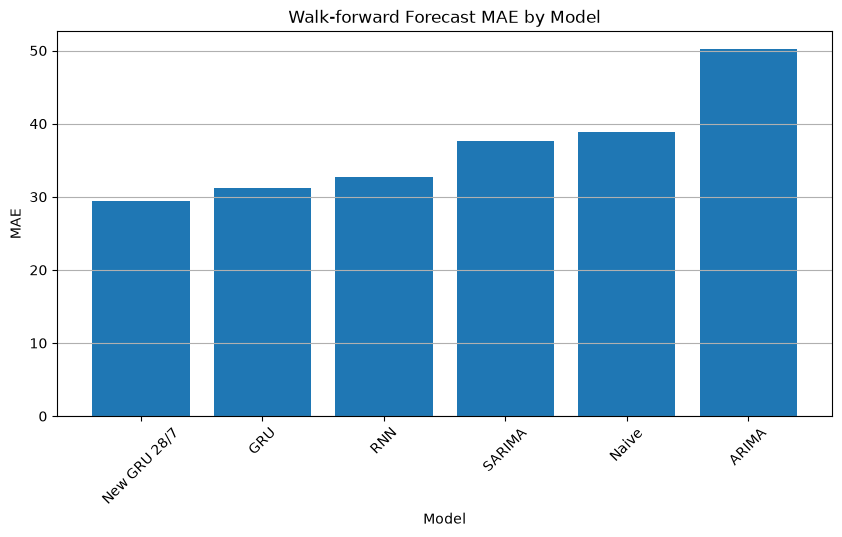

In [47]:
plt.figure(figsize=(10, 5))
plt.bar(overall_metrics_df["Model"], overall_metrics_df["MAE"])
plt.title("Walk-forward Forecast MAE by Model")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

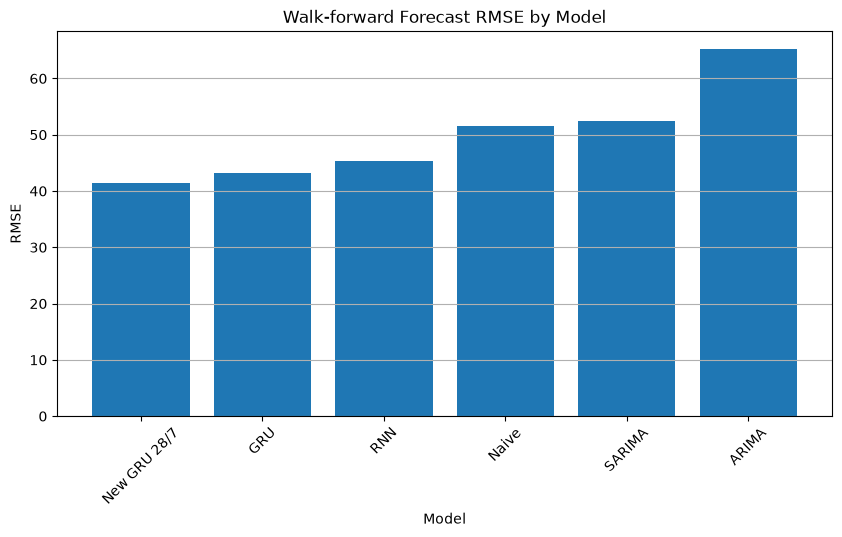

In [48]:
overall_rmse_df = overall_metrics_df.sort_values("RMSE").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(overall_rmse_df["Model"], overall_rmse_df["RMSE"])
plt.title("Walk-forward Forecast RMSE by Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

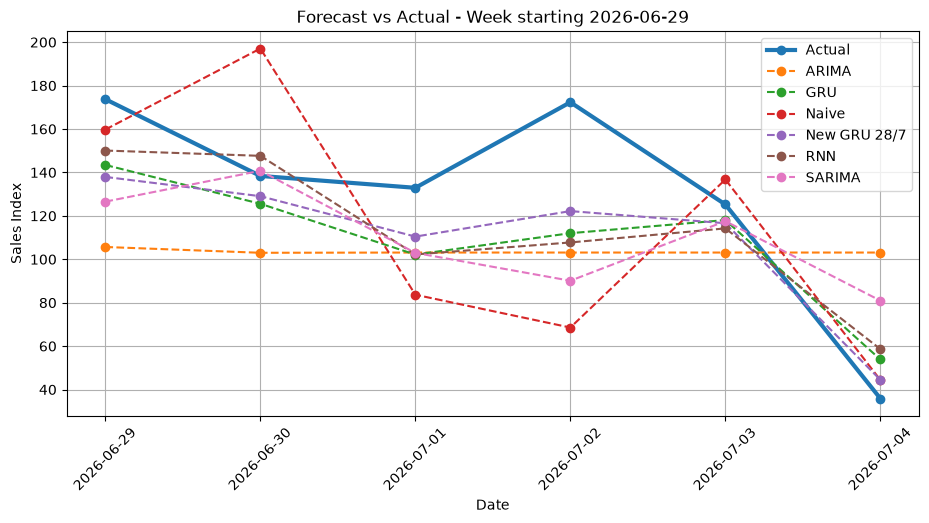

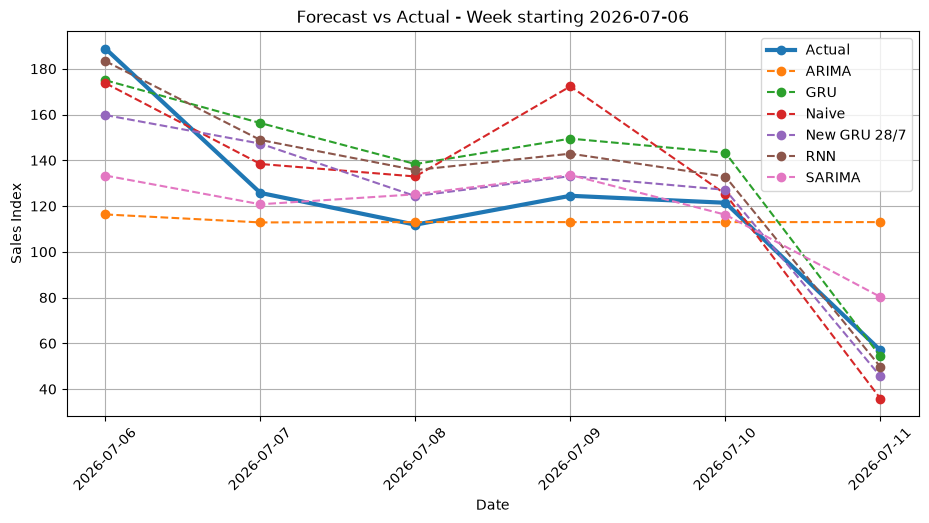

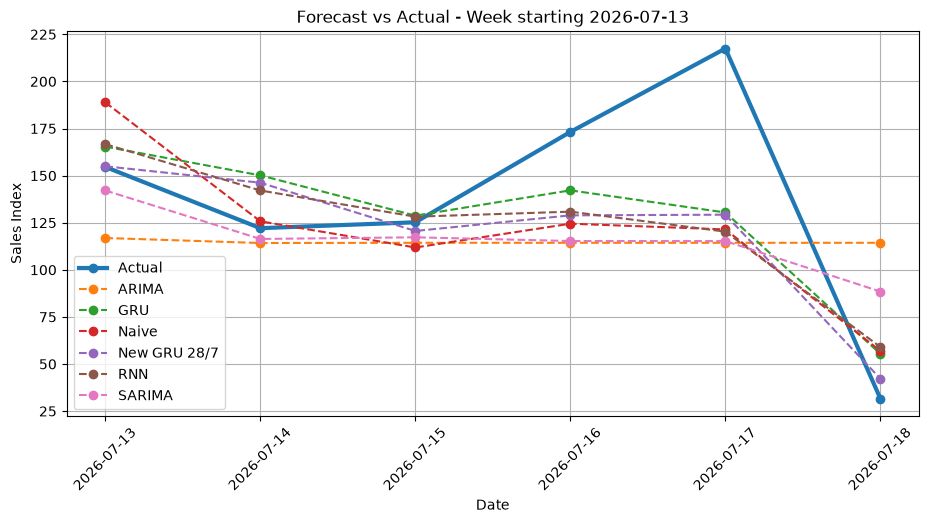

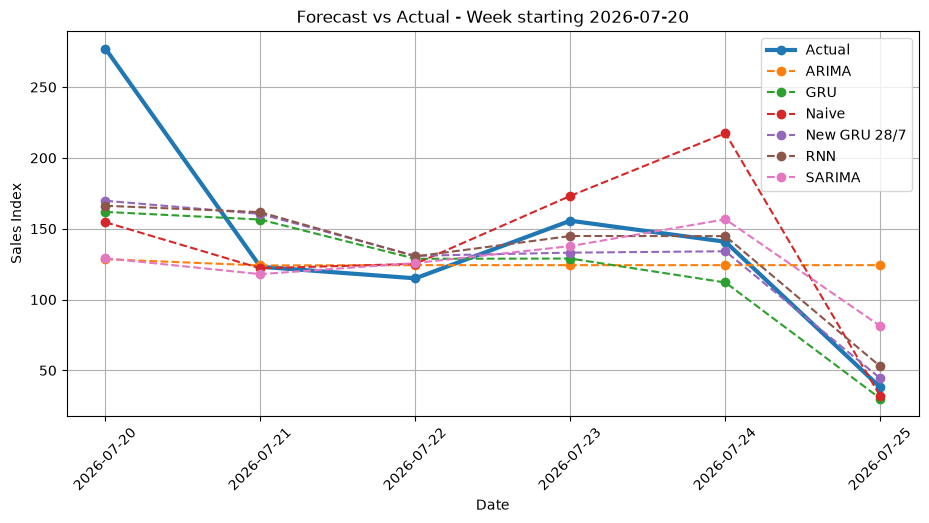

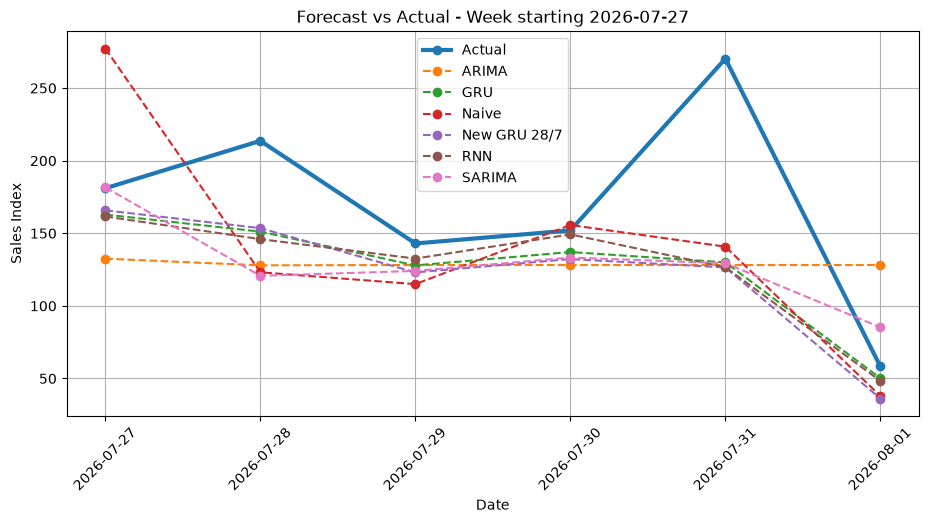

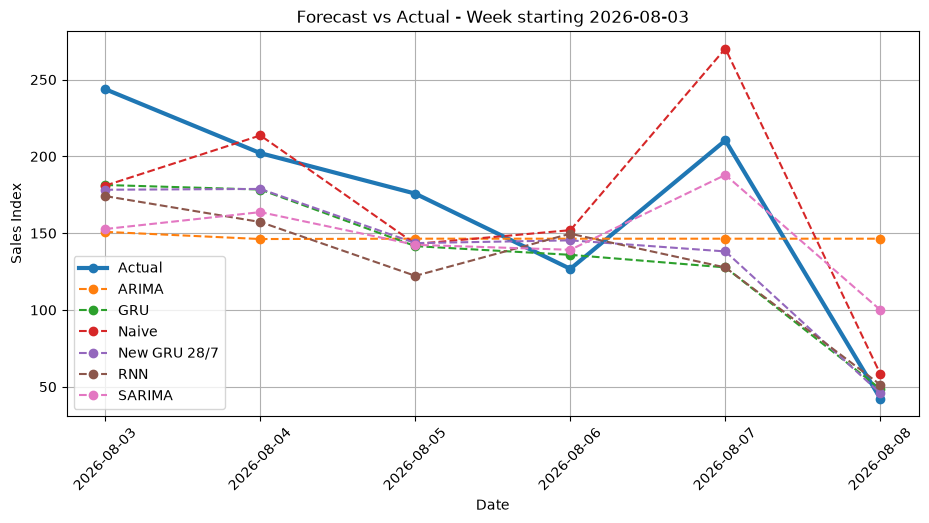

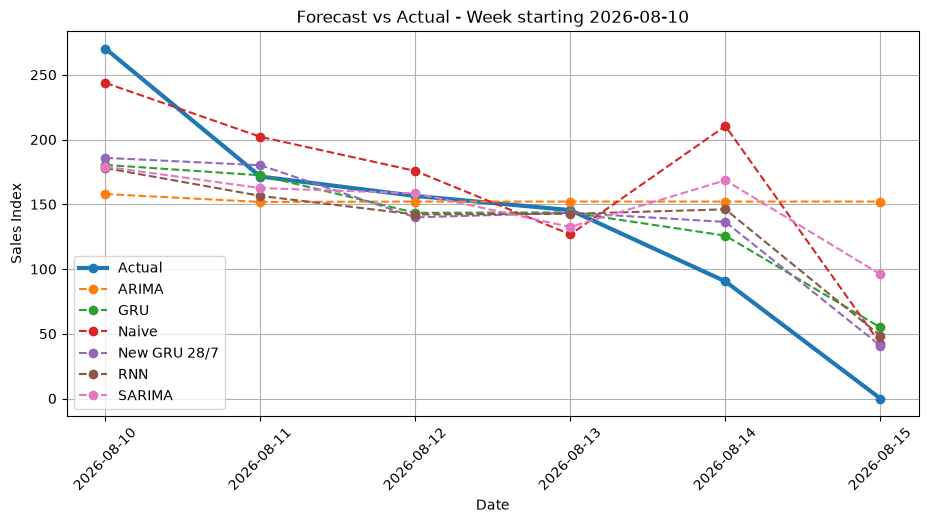

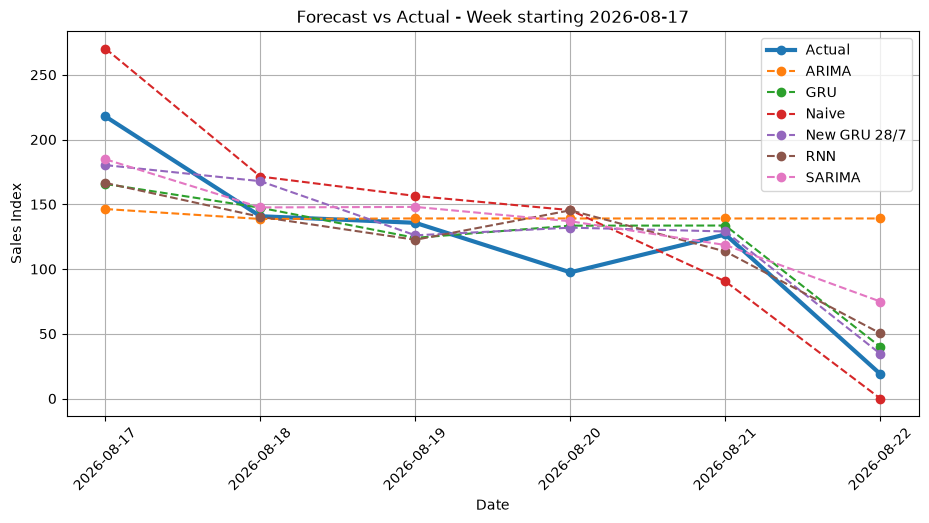

In [49]:
for week_start in sorted(all_results_df["week_start"].unique()):
    df_week = all_results_df[all_results_df["week_start"] == week_start].copy()

    plt.figure(figsize=(11, 5))

    actual_line = (
        df_week[["forecast_date", "y_true"]]
        .drop_duplicates()
        .sort_values("forecast_date")
    )

    plt.plot(
        actual_line["forecast_date"],
        actual_line["y_true"],
        marker="o",
        linewidth=3,
        label="Actual"
    )

    for model_name, df_model in df_week.groupby("model"):
        df_model = df_model.sort_values("forecast_date")

        plt.plot(
            df_model["forecast_date"],
            df_model["y_pred"],
            marker="o",
            linestyle="--",
            label=model_name
        )

    plt.title(f"Forecast vs Actual - Week starting {pd.Timestamp(week_start).date()}")
    plt.xlabel("Date")
    plt.ylabel("Sales Index")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.show()

In [50]:
all_results_df.to_csv("walk_forward_all_predictions.csv", index=False)
overall_metrics_df.to_csv("walk_forward_overall_metrics.csv", index=False)
weekly_metrics_df.to_csv("walk_forward_weekly_metrics.csv", index=False)
horizon_metrics_df.to_csv("walk_forward_horizon_metrics.csv", index=False)

The following plot compares the actual sales values with the forecasts from the two GRU-based models across the full 8-week holdout period. The vertical dashed lines separate the weekly walk-forward forecast windows.

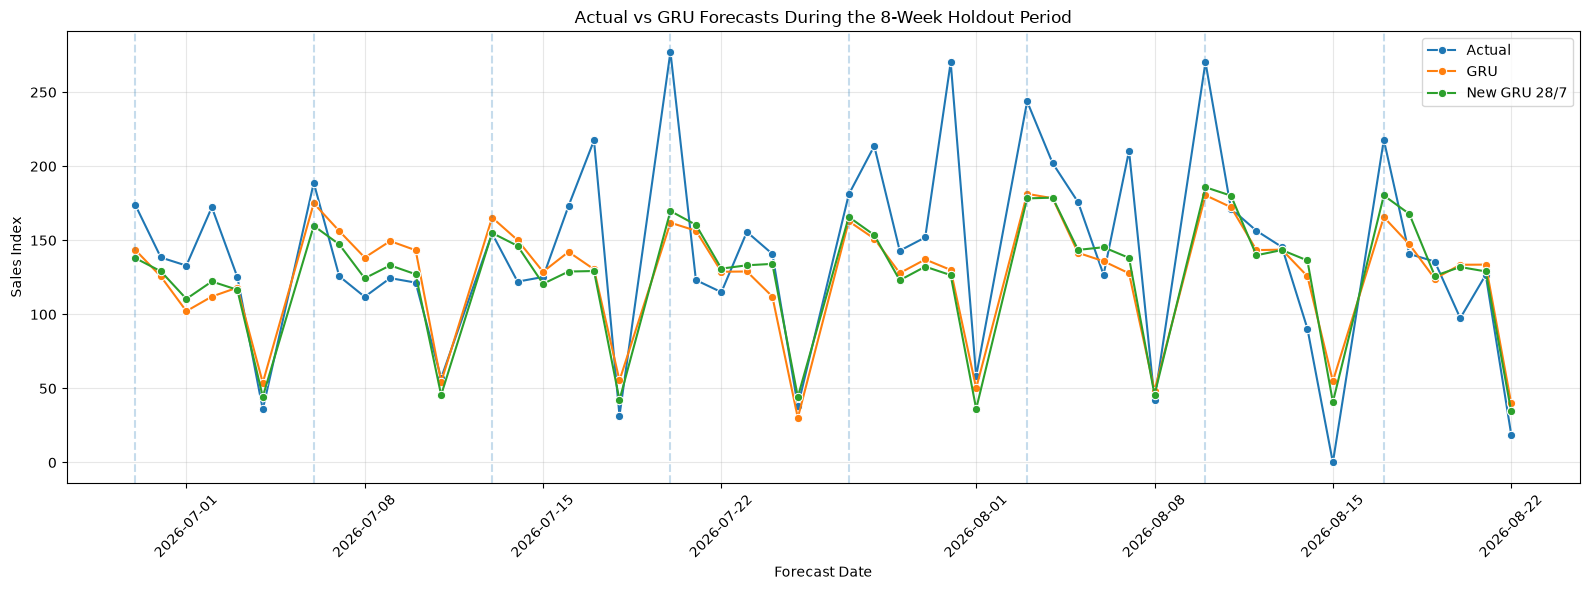

In [51]:
# Actual vs GRU models over the full holdout period

plot_gru = gru_results_df[
    ["forecast_date", "y_true", "y_pred"]
].copy()

plot_gru = plot_gru.rename(
    columns={
        "y_true": "Actual",
        "y_pred": "GRU"
    }
)

plot_new_gru = new_gru_results_df[
    ["forecast_date", "y_pred"]
].copy()

plot_new_gru = plot_new_gru.rename(
    columns={
        "y_pred": "New GRU 28/7"
    }
)

plot_df = plot_gru.merge(
    plot_new_gru,
    on="forecast_date",
    how="inner"
)

plot_long = plot_df.melt(
    id_vars="forecast_date",
    value_vars=["Actual", "GRU", "New GRU 28/7"],
    var_name="Series",
    value_name="Sales Index"
)

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=plot_long,
    x="forecast_date",
    y="Sales Index",
    hue="Series",
    marker="o"
)

for week_start in sorted(actual_sales["week_start"].unique()):
    plt.axvline(
        x=week_start,
        linestyle="--",
        alpha=0.25
    )

plt.title("Actual vs GRU Forecasts During the 8-Week Holdout Period")
plt.xlabel("Forecast Date")
plt.ylabel("Sales Index")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="")
plt.tight_layout()
plt.show()

In [52]:
display(overall_metrics_df)

,Model,MAE,RMSE
0,New GRU 28/7,29.443680,41.491018
1,GRU,31.187836,43.154534
2,RNN,32.717771,45.328012
3,SARIMA,37.692644,52.513470
4,Naive,38.826042,51.486631
5,ARIMA,50.149358,65.148995


Among the neural network models, the calendar-aware New GRU achieved the best overall walk-forward performance. The improvement was modest but consistent, especially at later forecast horizons. This suggests that adding calendar structure, Sunday zero-sales days, and weekday flags helped the model capture weekly sales patterns.

The final walk-forward evaluation showed that neural recurrent models outperformed classical statistical baselines. The standard GRU achieved the lowest error, with MAE = 29.05 and RMSE = 41.19, improving over the naive baseline by approximately 25% in MAE. However, the margin between the neural models was not large, and the forecasting task remains noisy because many important business drivers are not included in the data.     

The comparison plots show that the models capture the general sales pattern, but they struggle with some mid-week fluctuations. This is reasonable because daily e-commerce sales are affected by external factors that are not available in the dataset, such as inventory availability, supplier delays, cash-flow constraints, promotions, holidays, seasonality, and changes in product-level demand.

The evaluation period appears to be a relatively strong sales period for the business, which explains why the models often predict lower values than the actual sales. During weaker periods, the opposite behavior could also occur.

Therefore, the models should be used as decision-support tools rather than exact daily sales predictors. Their main value is in producing a reasonable baseline forecast that can help with short-term business planning, especially payment scheduling and cash-flow management.